In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import sys
sys.path.append(r'C:\Users\ASUS\Documents\DDM')

from ddm_core import simulate_ddm, fit_ddm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
# STUDY DESIGN — fixed before running anything
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations = 50                   # start with 10, change to 50 for final run

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 50
Total fits to run: 200


In [ ]:
results = []

for n in sample_sizes:
    for sim in range(n_simulations):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results)
df.to_csv('recovery_results.csv', index=False)
print(f"\nDone. Results saved to recovery_results.csv")

n=50, sim=1/50 | v=0.398 a=1.358 z=0.465 t0=0.141
n=50, sim=2/50 | v=0.877 a=1.241 z=0.319 t0=0.187
n=50, sim=3/50 | v=0.000 a=1.000 z=0.581 t0=0.182
n=50, sim=4/50 | v=0.000 a=1.178 z=0.609 t0=0.183
n=50, sim=5/50 | v=0.364 a=1.179 z=0.472 t0=0.153
n=50, sim=6/50 | v=0.989 a=1.163 z=0.411 t0=0.171
n=50, sim=7/50 | v=0.210 a=1.254 z=0.433 t0=0.169
n=50, sim=8/50 | v=0.480 a=1.310 z=0.444 t0=0.142
n=50, sim=9/50 | v=0.000 a=1.182 z=0.541 t0=0.162
n=50, sim=10/50 | v=0.225 a=1.160 z=0.495 t0=0.163
n=50, sim=11/50 | v=0.169 a=1.194 z=0.451 t0=0.149
n=50, sim=12/50 | v=0.798 a=1.225 z=0.425 t0=0.148
n=50, sim=13/50 | v=0.073 a=1.169 z=0.539 t0=0.174
n=50, sim=14/50 | v=0.584 a=1.173 z=0.469 t0=0.154
n=50, sim=15/50 | v=0.326 a=1.196 z=0.522 t0=0.174
n=50, sim=16/50 | v=0.161 a=1.180 z=0.472 t0=0.146
n=50, sim=17/50 | v=0.027 a=1.172 z=0.552 t0=0.158
n=50, sim=18/50 | v=0.327 a=1.232 z=0.459 t0=0.153
n=50, sim=19/50 | v=0.859 a=1.400 z=0.508 t0=0.153
n=50, sim=20/50 | v=0.541 a=1.241 z=0.49

In [41]:
df = pd.read_csv('recovery_results.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.50)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.50) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.333 |      1.229 |      0.502 |      0.159
   100 |      0.309 |      1.225 |      0.497 |      0.151
   200 |      0.323 |      1.232 |      0.500 |      0.153
   500 |      0.312 |      1.233 |      0.499 |      0.152


In [42]:
df = pd.read_csv('recovery_results.csv')

print("Bias (mean estimated - true) and RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'bias_v':>8} | {'bias_a':>8} | "
      f"{'bias_z':>8} | {'bias_t0':>8}")
print("-" * 65)

params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    biases = []
    for p in params:
        bias = (subset[f'est_{p}'] - true_vals[p]).mean()
        biases.append(bias)
    print(f"{n:>6} | {biases[0]:>8.4f} | {biases[1]:>8.4f} | "
          f"{biases[2]:>8.4f} | {biases[3]:>8.4f}")

print()
print("RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'rmse_v':>8} | {'rmse_a':>8} | "
      f"{'rmse_z':>8} | {'rmse_t0':>8}")
print("-" * 65)

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    rmses = []
    for p in params:
        rmse = np.sqrt(((subset[f'est_{p}'] - true_vals[p])**2).mean())
        rmses.append(rmse)
    print(f"{n:>6} | {rmses[0]:>8.4f} | {rmses[1]:>8.4f} | "
          f"{rmses[2]:>8.4f} | {rmses[3]:>8.4f}")

Bias (mean estimated - true) and RMSE by sample size:
     n |   bias_v |   bias_a |   bias_z |  bias_t0
-----------------------------------------------------------------
    50 |   0.0333 |   0.0288 |   0.0023 |   0.0087
   100 |   0.0091 |   0.0249 |  -0.0029 |   0.0012
   200 |   0.0234 |   0.0317 |  -0.0005 |   0.0026
   500 |   0.0118 |   0.0327 |  -0.0014 |   0.0018

RMSE by sample size:
     n |   rmse_v |   rmse_a |   rmse_z |  rmse_t0
-----------------------------------------------------------------
    50 |   0.2780 |   0.0828 |   0.0577 |   0.0185
   100 |   0.1813 |   0.0659 |   0.0294 |   0.0109
   200 |   0.1415 |   0.0528 |   0.0256 |   0.0076
   500 |   0.0799 |   0.0425 |   0.0148 |   0.0049


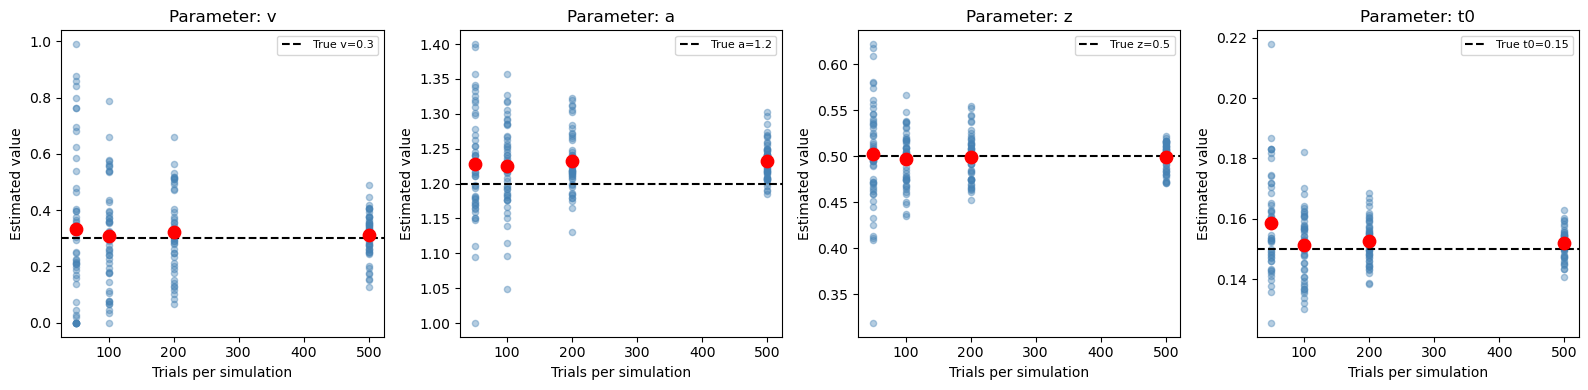

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.5, 0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df[df['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot.png', dpi=150)
plt.show()

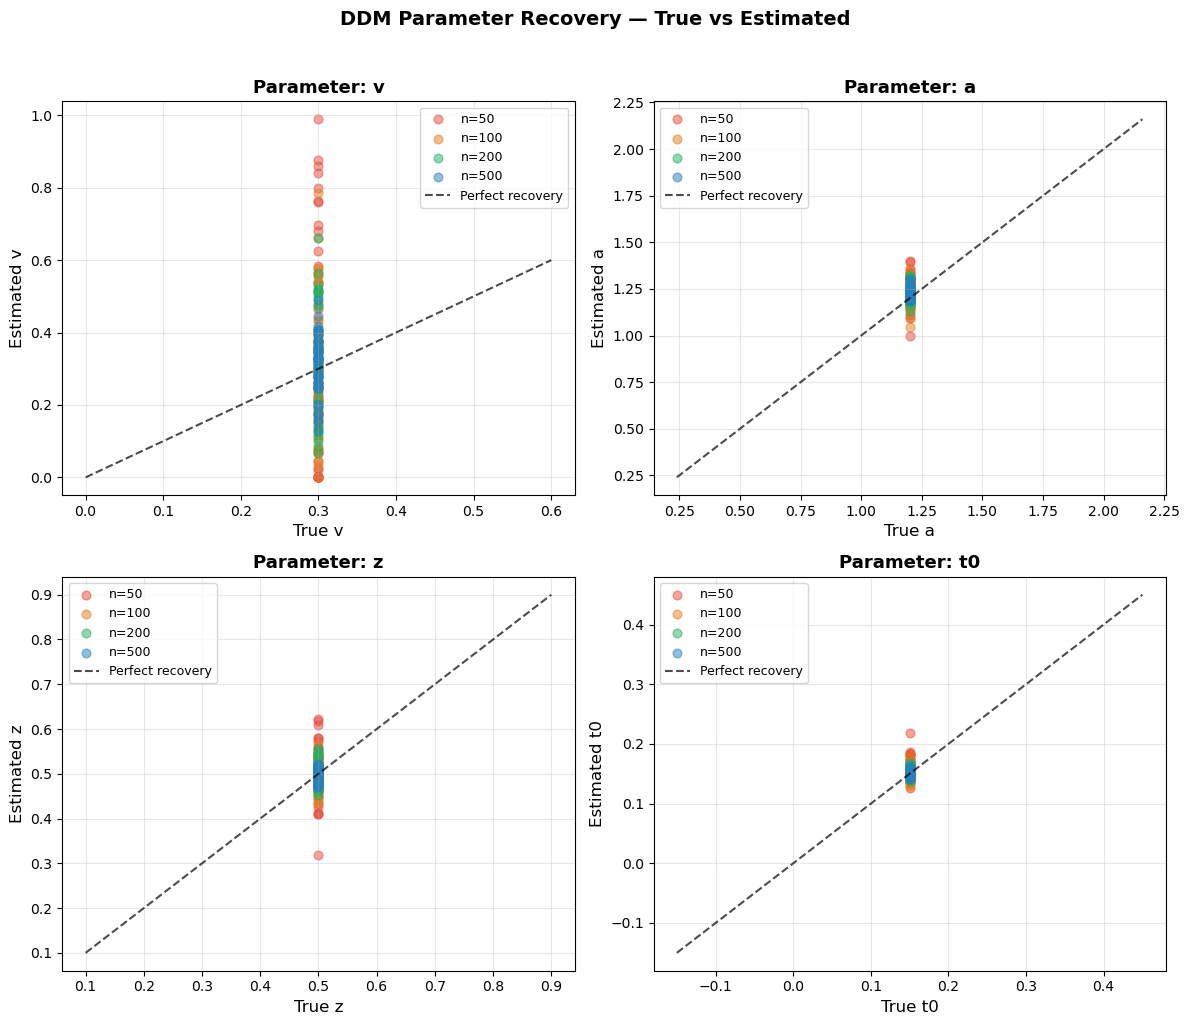

Figure saved as recovery_scatter.png


In [44]:
df = pd.read_csv('recovery_results.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter.png")

In [27]:
# STUDY DESIGN — fixed before running anything
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.7, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations = 50                   # start with 10, change to 50 for final run

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.7, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 50
Total fits to run: 200


In [28]:
results_07 = []

for n in sample_sizes:
    for sim in range(n_simulations):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results_07.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results_07)
df.to_csv('recovery_results_07.csv', index=False)
print(f"\nDone. Results saved to recovery_results_07.csv")

n=50, sim=1/50 | v=0.000 a=1.306 z=0.687 t0=0.148
n=50, sim=2/50 | v=0.362 a=1.200 z=0.694 t0=0.156
n=50, sim=3/50 | v=0.000 a=1.331 z=0.735 t0=0.152
n=50, sim=4/50 | v=0.101 a=1.271 z=0.672 t0=0.140
n=50, sim=5/50 | v=0.234 a=1.329 z=0.697 t0=0.151
n=50, sim=6/50 | v=0.519 a=1.317 z=0.661 t0=0.152
n=50, sim=7/50 | v=0.000 a=1.148 z=0.711 t0=0.158
n=50, sim=8/50 | v=0.077 a=1.213 z=0.722 t0=0.162
n=50, sim=9/50 | v=0.740 a=1.177 z=0.675 t0=0.153
n=50, sim=10/50 | v=5.000 a=5.000 z=0.050 t0=0.161
n=50, sim=11/50 | v=0.000 a=1.301 z=0.711 t0=0.153
n=50, sim=12/50 | v=0.409 a=1.215 z=0.670 t0=0.148
n=50, sim=13/50 | v=0.571 a=1.352 z=0.716 t0=0.157
n=50, sim=14/50 | v=0.137 a=1.253 z=0.682 t0=0.150
n=50, sim=15/50 | v=0.115 a=1.250 z=0.731 t0=0.145
n=50, sim=16/50 | v=0.290 a=1.178 z=0.665 t0=0.142
n=50, sim=17/50 | v=0.129 a=1.237 z=0.644 t0=0.145
n=50, sim=18/50 | v=0.760 a=1.256 z=0.683 t0=0.172
n=50, sim=19/50 | v=0.000 a=1.241 z=0.733 t0=0.155
n=50, sim=20/50 | v=0.055 a=1.309 z=0.64

In [29]:
df = pd.read_csv('recovery_results_07.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.70)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.70) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.575 |      1.476 |      0.652 |      0.153
   100 |      0.532 |      1.397 |      0.662 |      0.150
   200 |      0.512 |      1.398 |      0.665 |      0.149
   500 |      0.414 |      1.318 |      0.672 |      0.148


In [30]:
df = pd.read_csv('recovery_results_07.csv')

print("Bias (mean estimated - true) and RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'bias_v':>8} | {'bias_a':>8} | "
      f"{'bias_z':>8} | {'bias_t0':>8}")
print("-" * 65)

params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.7, 't0': 0.15}

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    biases = []
    for p in params:
        bias = (subset[f'est_{p}'] - true_vals[p]).mean()
        biases.append(bias)
    print(f"{n:>6} | {biases[0]:>8.4f} | {biases[1]:>8.4f} | "
          f"{biases[2]:>8.4f} | {biases[3]:>8.4f}")

print()
print("RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'rmse_v':>8} | {'rmse_a':>8} | "
      f"{'rmse_z':>8} | {'rmse_t0':>8}")
print("-" * 65)

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    rmses = []
    for p in params:
        rmse = np.sqrt(((subset[f'est_{p}'] - true_vals[p])**2).mean())
        rmses.append(rmse)
    print(f"{n:>6} | {rmses[0]:>8.4f} | {rmses[1]:>8.4f} | "
          f"{rmses[2]:>8.4f} | {rmses[3]:>8.4f}")

Bias (mean estimated - true) and RMSE by sample size:
     n |   bias_v |   bias_a |   bias_z |  bias_t0
-----------------------------------------------------------------
    50 |   0.2749 |   0.2759 |  -0.0477 |   0.0029
   100 |   0.2319 |   0.1967 |  -0.0380 |   0.0004
   200 |   0.2122 |   0.1980 |  -0.0353 |  -0.0005
   500 |   0.1144 |   0.1182 |  -0.0282 |  -0.0025

RMSE by sample size:
     n |   rmse_v |   rmse_a |   rmse_z |  rmse_t0
-----------------------------------------------------------------
    50 |   1.1791 |   0.9350 |   0.1632 |   0.0076
   100 |   0.9646 |   0.7635 |   0.1337 |   0.0063
   200 |   0.9537 |   0.7623 |   0.1316 |   0.0032
   500 |   0.6098 |   0.5399 |   0.0940 |   0.0032


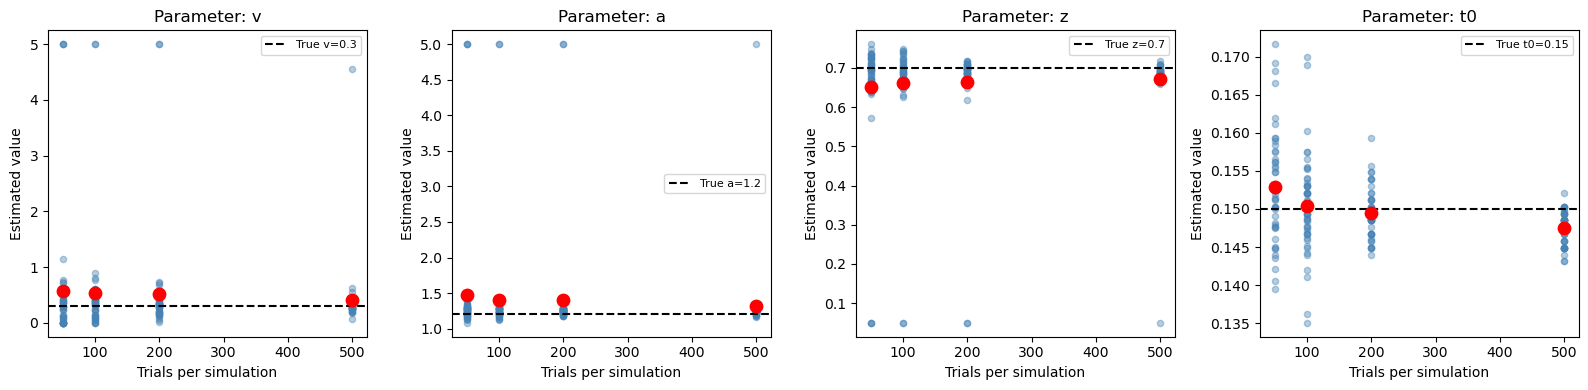

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.7, 0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df[df['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot_07.png', dpi=150)
plt.show()

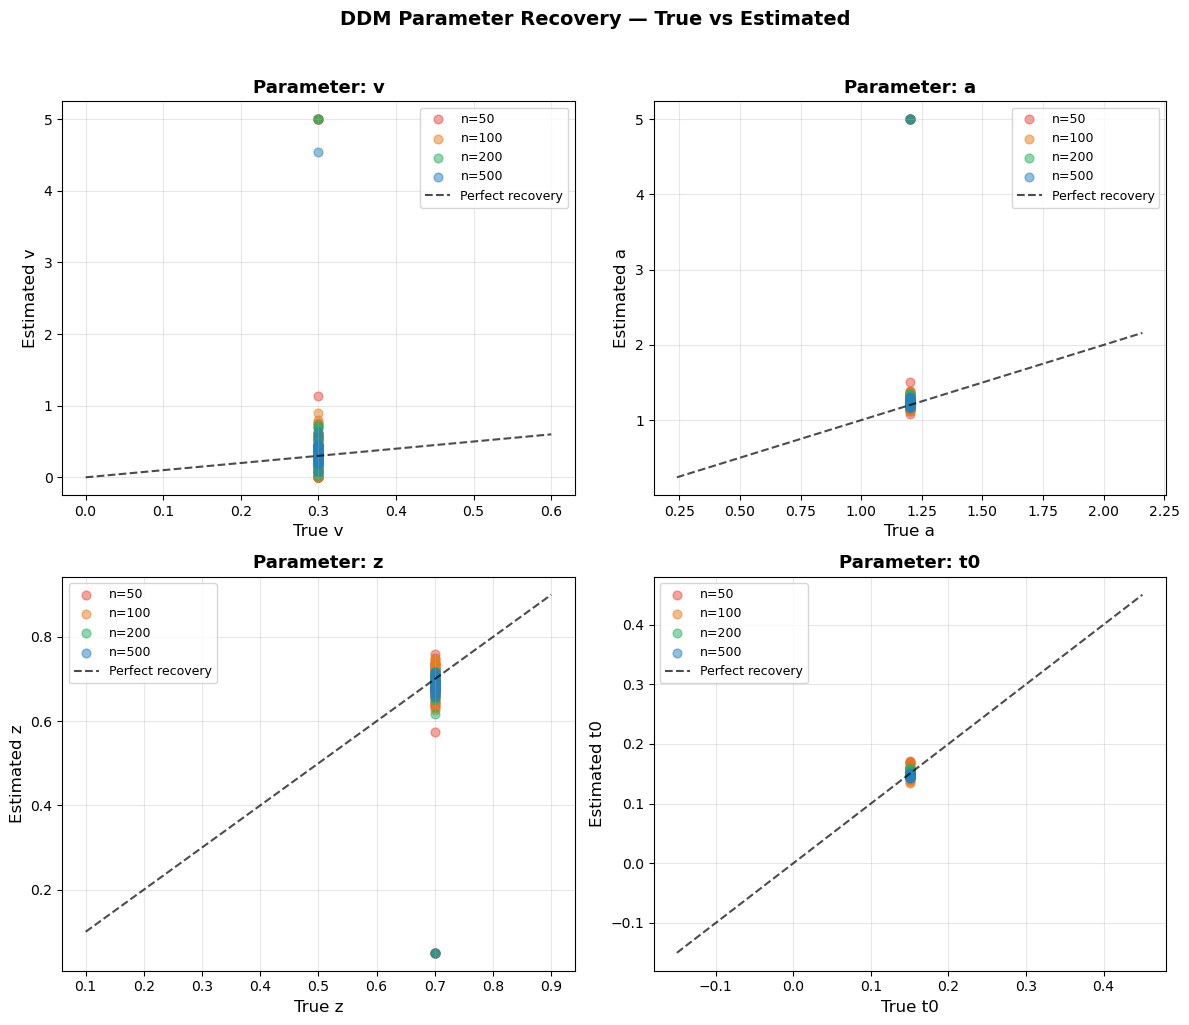

Figure saved as recovery_scatter_07.png


In [32]:
df = pd.read_csv('recovery_results_07.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter_07.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter_07.png")

In [33]:
# STUDY DESIGN — fixed before running anything
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations = 50                   # start with 10, change to 50 for final run

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 50
Total fits to run: 200


In [34]:
results_03 = []

for n in sample_sizes:
    for sim in range(n_simulations):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results_03.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results_03)
df.to_csv('recovery_results_03.csv', index=False)
print(f"\nDone. Results saved to recovery_results_03.csv")

n=50, sim=1/50 | v=0.423 a=1.233 z=0.289 t0=0.155
n=50, sim=2/50 | v=0.243 a=1.273 z=0.331 t0=0.150
n=50, sim=3/50 | v=0.000 a=1.173 z=0.324 t0=0.158
n=50, sim=4/50 | v=0.383 a=1.319 z=0.226 t0=0.154
n=50, sim=5/50 | v=0.178 a=1.306 z=0.251 t0=0.173
n=50, sim=6/50 | v=0.803 a=1.249 z=0.241 t0=0.158
n=50, sim=7/50 | v=0.640 a=1.166 z=0.309 t0=0.170
n=50, sim=8/50 | v=0.723 a=1.287 z=0.260 t0=0.147
n=50, sim=9/50 | v=0.653 a=1.419 z=0.240 t0=0.151
n=50, sim=10/50 | v=0.849 a=1.109 z=0.259 t0=0.163
n=50, sim=11/50 | v=0.274 a=1.362 z=0.280 t0=0.147
n=50, sim=12/50 | v=0.285 a=1.263 z=0.255 t0=0.161
n=50, sim=13/50 | v=0.171 a=1.174 z=0.316 t0=0.157
n=50, sim=14/50 | v=0.000 a=1.080 z=0.360 t0=0.149
n=50, sim=15/50 | v=0.000 a=1.200 z=0.292 t0=0.170
n=50, sim=16/50 | v=0.032 a=1.276 z=0.330 t0=0.146
n=50, sim=17/50 | v=0.474 a=1.386 z=0.237 t0=0.147
n=50, sim=18/50 | v=0.000 a=1.138 z=0.413 t0=0.149
n=50, sim=19/50 | v=0.252 a=1.201 z=0.329 t0=0.152
n=50, sim=20/50 | v=0.833 a=1.215 z=0.25

In [35]:
df = pd.read_csv('recovery_results_03.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.30)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.30) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.331 |      1.248 |      0.301 |      0.155
   100 |      0.324 |      1.243 |      0.302 |      0.152
   200 |      0.283 |      1.240 |      0.309 |      0.150
   500 |      0.280 |      1.247 |      0.311 |      0.148


In [36]:
df = pd.read_csv('recovery_results_03.csv')

print("Bias (mean estimated - true) and RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'bias_v':>8} | {'bias_a':>8} | "
      f"{'bias_z':>8} | {'bias_t0':>8}")
print("-" * 65)

params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    biases = []
    for p in params:
        bias = (subset[f'est_{p}'] - true_vals[p]).mean()
        biases.append(bias)
    print(f"{n:>6} | {biases[0]:>8.4f} | {biases[1]:>8.4f} | "
          f"{biases[2]:>8.4f} | {biases[3]:>8.4f}")

print()
print("RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'rmse_v':>8} | {'rmse_a':>8} | "
      f"{'rmse_z':>8} | {'rmse_t0':>8}")
print("-" * 65)

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    rmses = []
    for p in params:
        rmse = np.sqrt(((subset[f'est_{p}'] - true_vals[p])**2).mean())
        rmses.append(rmse)
    print(f"{n:>6} | {rmses[0]:>8.4f} | {rmses[1]:>8.4f} | "
          f"{rmses[2]:>8.4f} | {rmses[3]:>8.4f}")

Bias (mean estimated - true) and RMSE by sample size:
     n |   bias_v |   bias_a |   bias_z |  bias_t0
-----------------------------------------------------------------
    50 |   0.0314 |   0.0481 |   0.0009 |   0.0047
   100 |   0.0244 |   0.0431 |   0.0019 |   0.0022
   200 |  -0.0170 |   0.0396 |   0.0088 |  -0.0001
   500 |  -0.0195 |   0.0467 |   0.0106 |  -0.0020

RMSE by sample size:
     n |   rmse_v |   rmse_a |   rmse_z |  rmse_t0
-----------------------------------------------------------------
    50 |   0.2931 |   0.0949 |   0.0431 |   0.0105
   100 |   0.1896 |   0.0728 |   0.0249 |   0.0057
   200 |   0.1610 |   0.0570 |   0.0232 |   0.0038
   500 |   0.0887 |   0.0545 |   0.0151 |   0.0034


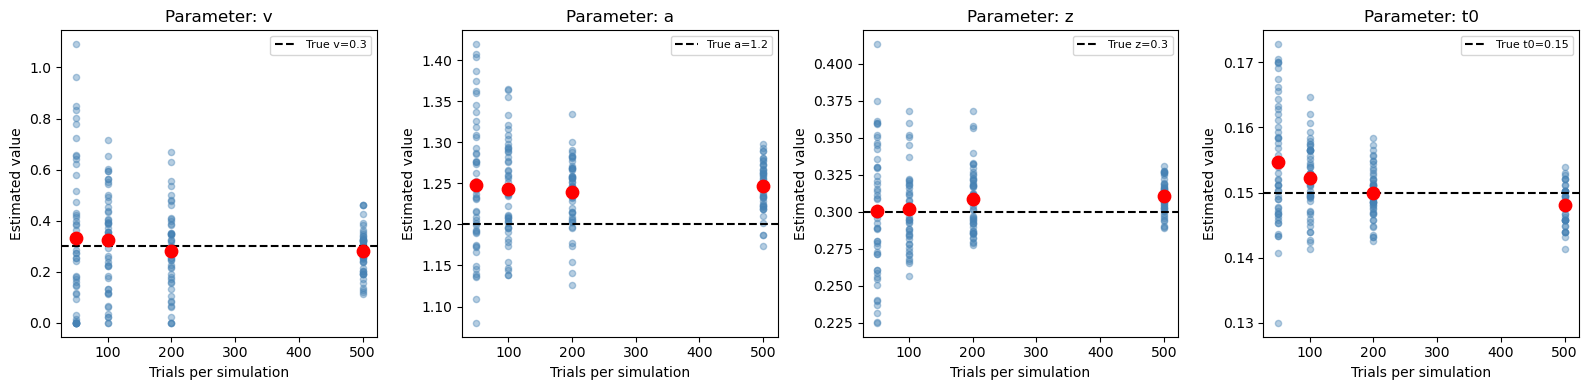

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.3, 0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df[df['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot_03.png', dpi=150)
plt.show()

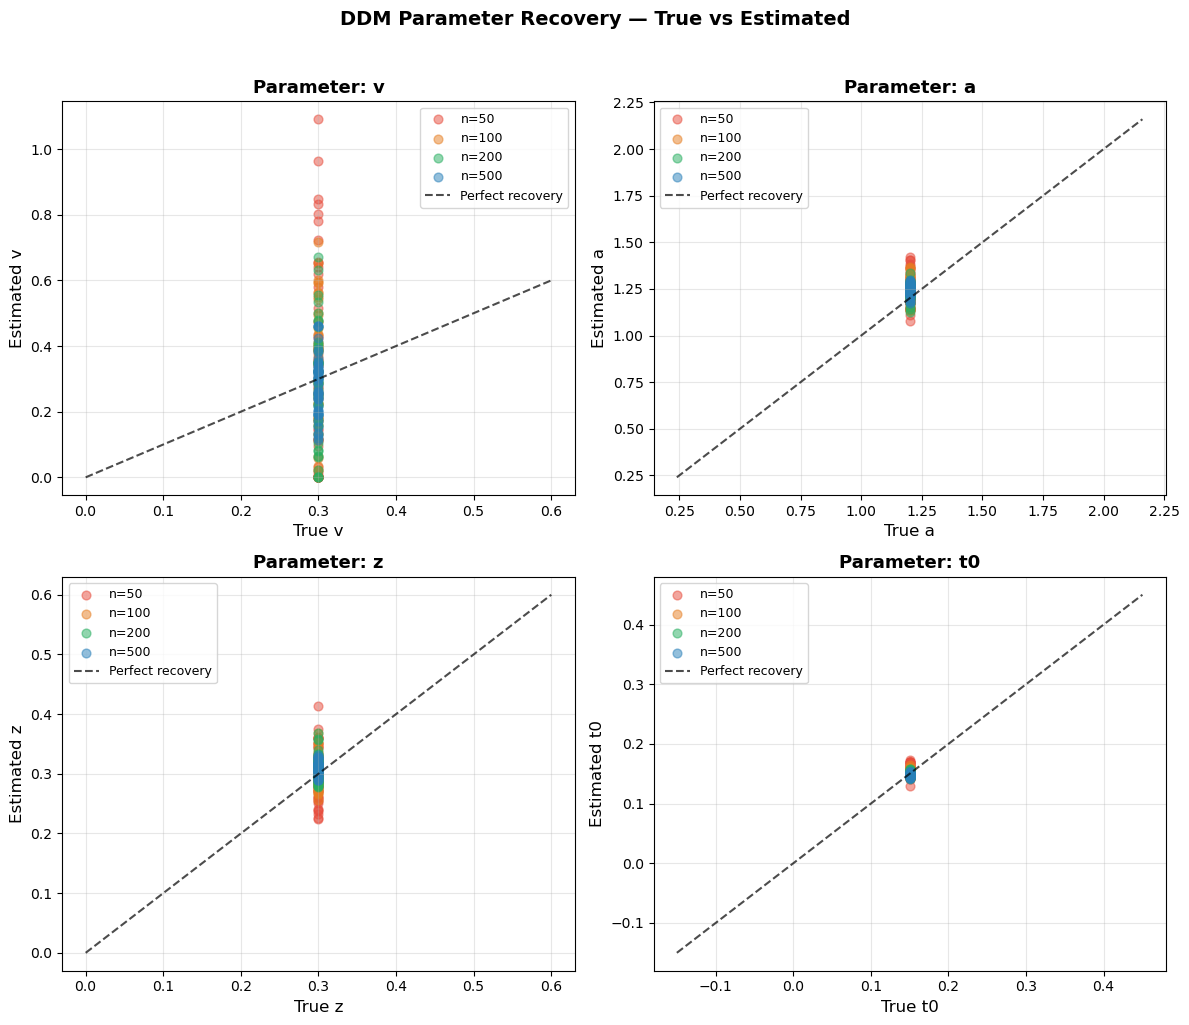

Figure saved as recovery_scatter_03.png


In [38]:
df = pd.read_csv('recovery_results_03.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter_03.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter_03.png")

In [45]:
# STUDY DESIGN — fixed before running anything
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations = 500                  # start with 10, change to 50 for final run

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 500
Total fits to run: 2000


In [46]:
results_500 =[]

for n in sample_sizes:
    for sim in range(n_simulations):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results_500.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results_500)
df.to_csv('recovery_results_500.csv', index=False)
print(f"\nDone. Results saved to recovery_results_500.csv")

n=50, sim=1/500 | v=1.140 a=1.155 z=0.382 t0=0.176
n=50, sim=2/500 | v=0.393 a=1.182 z=0.466 t0=0.161
n=50, sim=3/500 | v=0.543 a=1.287 z=0.444 t0=0.143
n=50, sim=4/500 | v=0.629 a=1.126 z=0.513 t0=0.179
n=50, sim=5/500 | v=0.409 a=1.291 z=0.534 t0=0.156
n=50, sim=6/500 | v=0.538 a=1.179 z=0.530 t0=0.156
n=50, sim=7/500 | v=0.359 a=1.224 z=0.469 t0=0.139
n=50, sim=8/500 | v=0.644 a=1.236 z=0.467 t0=0.147
n=50, sim=9/500 | v=0.125 a=1.260 z=0.562 t0=0.166
n=50, sim=10/500 | v=0.000 a=1.146 z=0.539 t0=0.173
n=50, sim=11/500 | v=0.093 a=1.281 z=0.490 t0=0.136
n=50, sim=12/500 | v=0.531 a=1.092 z=0.497 t0=0.173
n=50, sim=13/500 | v=0.316 a=1.180 z=0.487 t0=0.172
n=50, sim=14/500 | v=0.000 a=1.383 z=0.504 t0=0.147
n=50, sim=15/500 | v=0.114 a=1.316 z=0.502 t0=0.173
n=50, sim=16/500 | v=0.000 a=1.220 z=0.448 t0=0.178
n=50, sim=17/500 | v=0.463 a=1.188 z=0.506 t0=0.154
n=50, sim=18/500 | v=0.000 a=1.255 z=0.623 t0=0.152
n=50, sim=19/500 | v=0.000 a=1.178 z=0.520 t0=0.139
n=50, sim=20/500 | v=

In [47]:
df = pd.read_csv('recovery_results_500.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.50)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.50) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.324 |      1.226 |      0.501 |      0.159
   100 |      0.304 |      1.231 |      0.502 |      0.155
   200 |      0.295 |      1.235 |      0.501 |      0.152
   500 |      0.300 |      1.236 |      0.500 |      0.151


In [48]:
df = pd.read_csv('recovery_results_500.csv')

print("Bias (mean estimated - true) and RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'bias_v':>8} | {'bias_a':>8} | "
      f"{'bias_z':>8} | {'bias_t0':>8}")
print("-" * 65)

params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    biases = []
    for p in params:
        bias = (subset[f'est_{p}'] - true_vals[p]).mean()
        biases.append(bias)
    print(f"{n:>6} | {biases[0]:>8.4f} | {biases[1]:>8.4f} | "
          f"{biases[2]:>8.4f} | {biases[3]:>8.4f}")

print()
print("RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'rmse_v':>8} | {'rmse_a':>8} | "
      f"{'rmse_z':>8} | {'rmse_t0':>8}")
print("-" * 65)

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    rmses = []
    for p in params:
        rmse = np.sqrt(((subset[f'est_{p}'] - true_vals[p])**2).mean())
        rmses.append(rmse)
    print(f"{n:>6} | {rmses[0]:>8.4f} | {rmses[1]:>8.4f} | "
          f"{rmses[2]:>8.4f} | {rmses[3]:>8.4f}")

Bias (mean estimated - true) and RMSE by sample size:
     n |   bias_v |   bias_a |   bias_z |  bias_t0
-----------------------------------------------------------------
    50 |   0.0242 |   0.0257 |   0.0010 |   0.0091
   100 |   0.0038 |   0.0309 |   0.0023 |   0.0048
   200 |  -0.0049 |   0.0351 |   0.0013 |   0.0021
   500 |   0.0003 |   0.0364 |  -0.0001 |   0.0010

RMSE by sample size:
     n |   rmse_v |   rmse_a |   rmse_z |  rmse_t0
-----------------------------------------------------------------
    50 |   0.2618 |   0.0841 |   0.0523 |   0.0175
   100 |   0.1943 |   0.0649 |   0.0364 |   0.0119
   200 |   0.1430 |   0.0543 |   0.0251 |   0.0074
   500 |   0.0886 |   0.0442 |   0.0155 |   0.0047


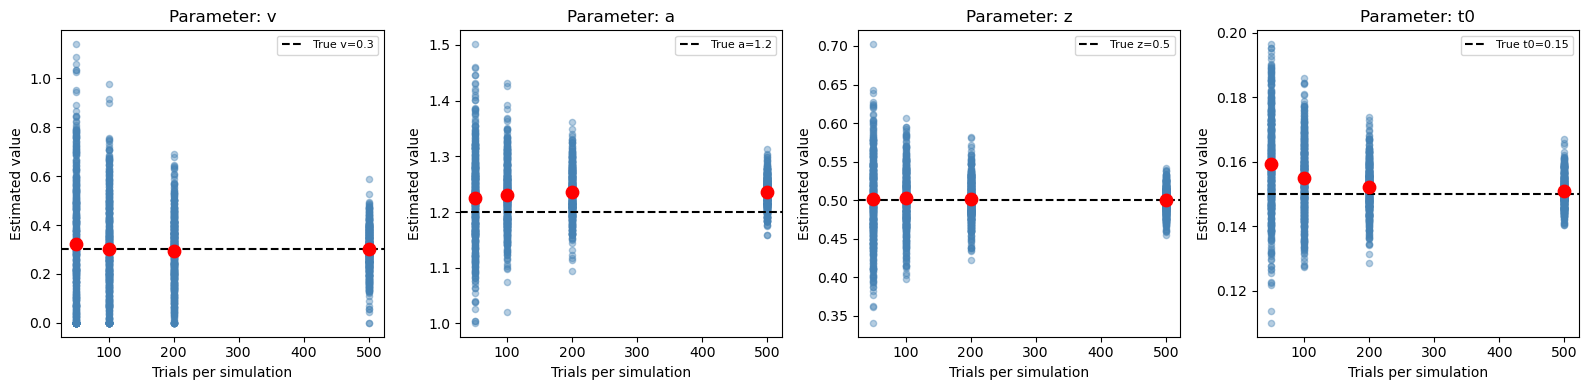

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.5, 0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df[df['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot_500.png', dpi=150)
plt.show()

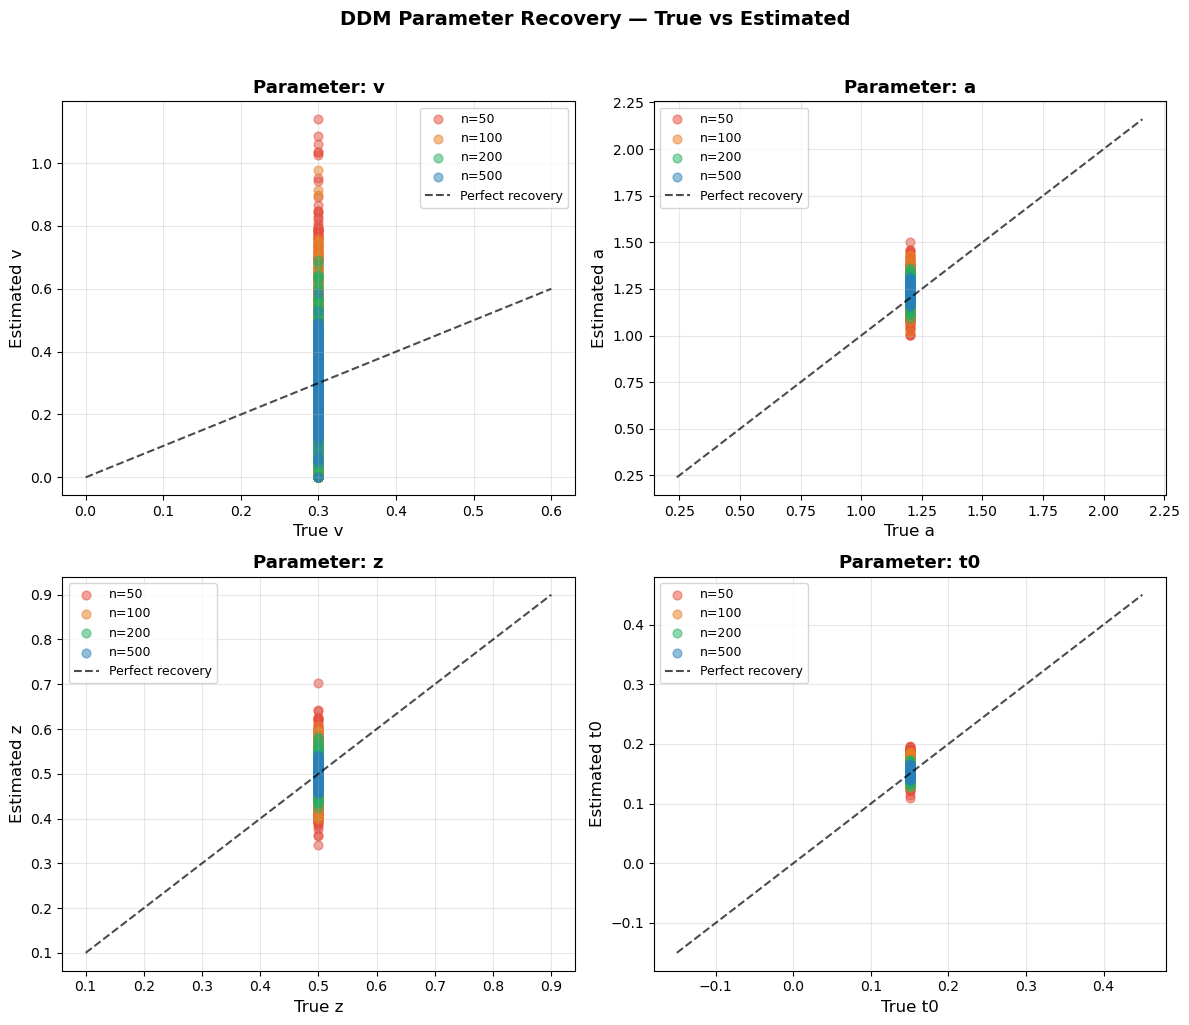

Figure saved as recovery_scatter_500.png


In [50]:
df = pd.read_csv('recovery_results_500.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.5, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter_500.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter_500.png")

In [51]:
# STUDY DESIGN — fixed before running anything
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.7, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations = 500                  # start with 10, change to 50 for final run

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.7, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 500
Total fits to run: 2000


In [52]:
results_500_07 = []

for n in sample_sizes:
    for sim in range(n_simulations):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results_500_07.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results_500_07)
df.to_csv('recovery_results_500_07.csv', index=False)
print(f"\nDone. Results saved to recovery_results_500_07.csv")

n=50, sim=1/500 | v=0.639 a=1.261 z=0.633 t0=0.143
n=50, sim=2/500 | v=0.000 a=1.170 z=0.699 t0=0.146
n=50, sim=3/500 | v=0.000 a=1.154 z=0.720 t0=0.152
n=50, sim=4/500 | v=0.343 a=1.364 z=0.704 t0=0.149
n=50, sim=5/500 | v=0.088 a=1.245 z=0.740 t0=0.167
n=50, sim=6/500 | v=0.202 a=1.236 z=0.645 t0=0.143
n=50, sim=7/500 | v=0.020 a=1.292 z=0.776 t0=0.158
n=50, sim=8/500 | v=0.088 a=1.351 z=0.781 t0=0.169
n=50, sim=9/500 | v=0.000 a=1.382 z=0.730 t0=0.141
n=50, sim=10/500 | v=0.193 a=1.243 z=0.737 t0=0.157
n=50, sim=11/500 | v=0.071 a=1.262 z=0.723 t0=0.159
n=50, sim=12/500 | v=0.517 a=1.225 z=0.676 t0=0.142
n=50, sim=13/500 | v=0.009 a=1.337 z=0.738 t0=0.154
n=50, sim=14/500 | v=0.000 a=1.307 z=0.731 t0=0.152
n=50, sim=15/500 | v=0.140 a=1.279 z=0.723 t0=0.150
n=50, sim=16/500 | v=0.041 a=1.258 z=0.729 t0=0.166
n=50, sim=17/500 | v=0.429 a=1.226 z=0.702 t0=0.153
n=50, sim=18/500 | v=0.168 a=1.140 z=0.700 t0=0.156
n=50, sim=19/500 | v=0.236 a=1.185 z=0.685 t0=0.151
n=50, sim=20/500 | v=

In [53]:
df = pd.read_csv('recovery_results_500_07.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.70)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.70) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.342 |      1.243 |      0.696 |      0.153
   100 |      0.320 |      1.238 |      0.694 |      0.151
   200 |      0.321 |      1.243 |      0.689 |      0.149
   500 |      0.341 |      1.244 |      0.684 |      0.148


In [54]:
df = pd.read_csv('recovery_results_500_07.csv')

print("Bias (mean estimated - true) and RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'bias_v':>8} | {'bias_a':>8} | "
      f"{'bias_z':>8} | {'bias_t0':>8}")
print("-" * 65)

params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.7, 't0': 0.15}

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    biases = []
    for p in params:
        bias = (subset[f'est_{p}'] - true_vals[p]).mean()
        biases.append(bias)
    print(f"{n:>6} | {biases[0]:>8.4f} | {biases[1]:>8.4f} | "
          f"{biases[2]:>8.4f} | {biases[3]:>8.4f}")

print()
print("RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'rmse_v':>8} | {'rmse_a':>8} | "
      f"{'rmse_z':>8} | {'rmse_t0':>8}")
print("-" * 65)

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    rmses = []
    for p in params:
        rmse = np.sqrt(((subset[f'est_{p}'] - true_vals[p])**2).mean())
        rmses.append(rmse)
    print(f"{n:>6} | {rmses[0]:>8.4f} | {rmses[1]:>8.4f} | "
          f"{rmses[2]:>8.4f} | {rmses[3]:>8.4f}")

Bias (mean estimated - true) and RMSE by sample size:
     n |   bias_v |   bias_a |   bias_z |  bias_t0
-----------------------------------------------------------------
    50 |   0.0423 |   0.0431 |  -0.0042 |   0.0028
   100 |   0.0202 |   0.0376 |  -0.0058 |   0.0008
   200 |   0.0209 |   0.0431 |  -0.0112 |  -0.0007
   500 |   0.0415 |   0.0442 |  -0.0159 |  -0.0025

RMSE by sample size:
     n |   rmse_v |   rmse_a |   rmse_z |  rmse_t0
-----------------------------------------------------------------
    50 |   0.2957 |   0.1047 |   0.0430 |   0.0092
   100 |   0.2054 |   0.0720 |   0.0294 |   0.0055
   200 |   0.1470 |   0.0624 |   0.0229 |   0.0038
   500 |   0.1070 |   0.0519 |   0.0202 |   0.0035


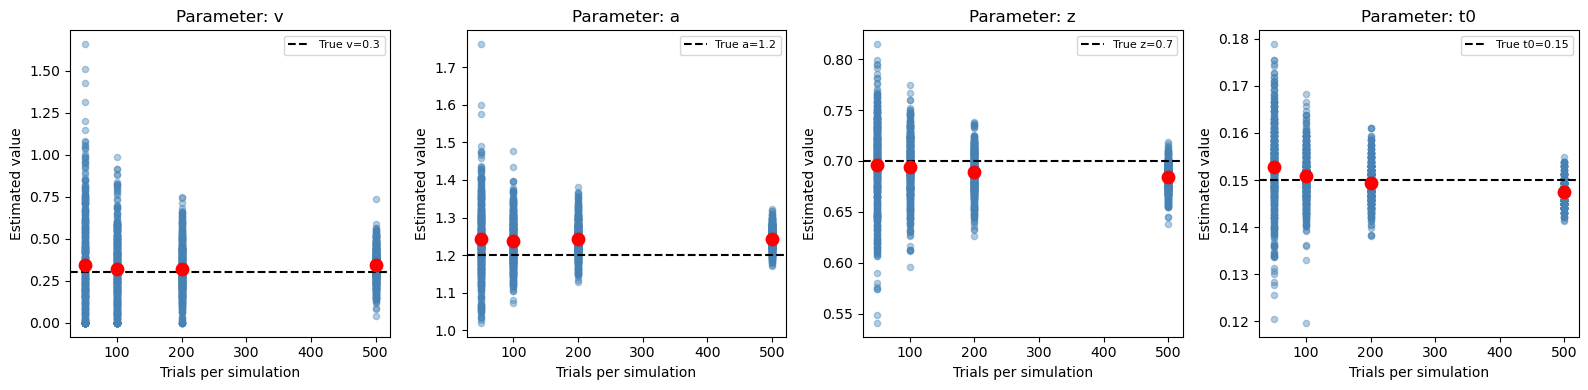

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.7, 0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df[df['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot_500_07.png', dpi=150)
plt.show()

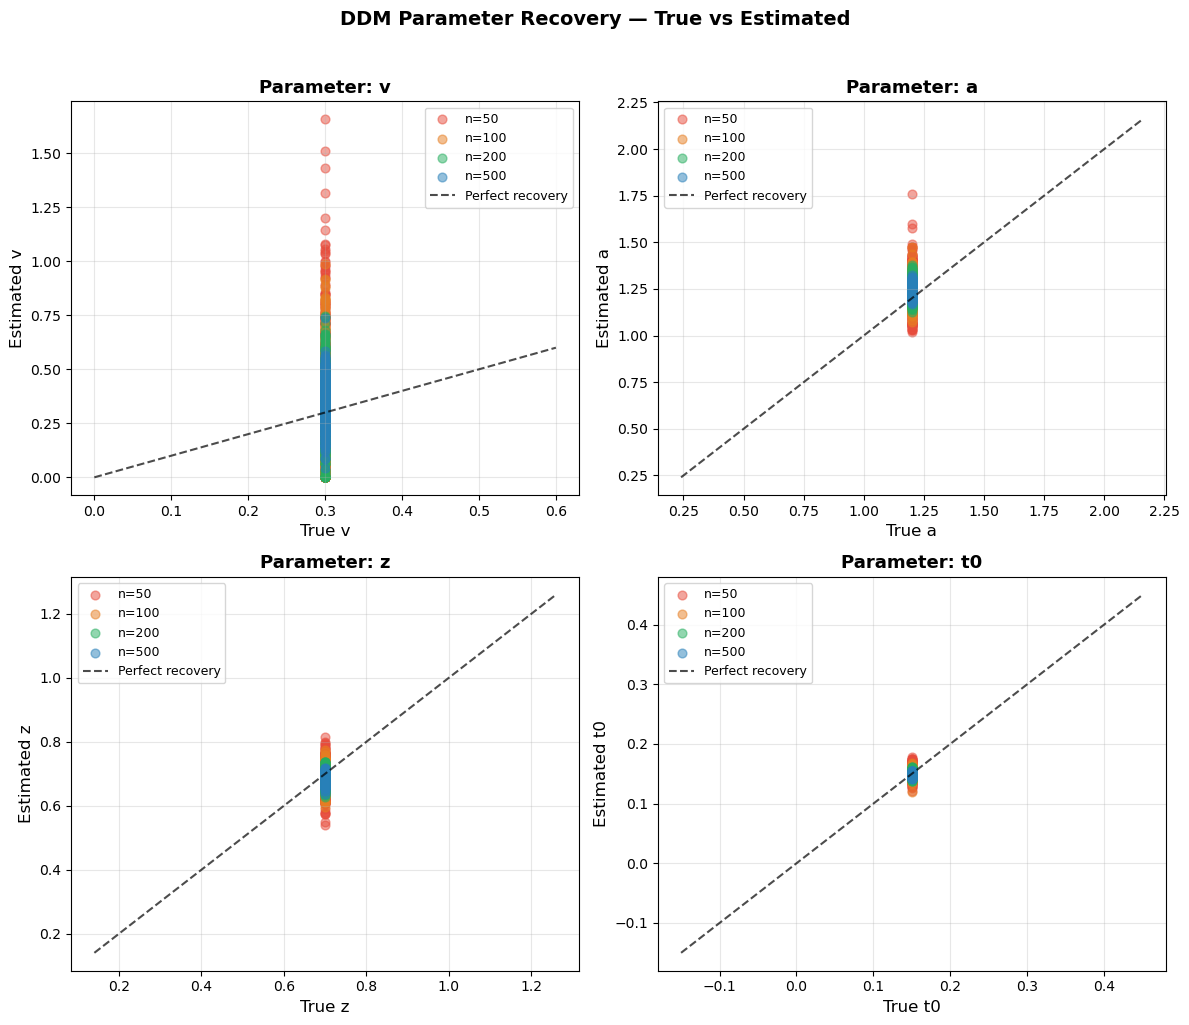

Figure saved as recovery_scatter_500_07.png


In [56]:
df = pd.read_csv('recovery_results_500_07.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.7, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter_500_07.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter_500_07.png")

In [57]:
# STUDY DESIGN — fixed before running anything
true_params = {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}

sample_sizes = [50, 100, 200, 500]   # trials per simulation
n_simulations = 500                  # start with 10, change to 50 for final run

print("Study design:")
print(f"True parameters: {true_params}")
print(f"Sample sizes: {sample_sizes}")
print(f"Simulations per condition: {n_simulations}")
print(f"Total fits to run: {len(sample_sizes) * n_simulations}")

Study design:
True parameters: {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}
Sample sizes: [50, 100, 200, 500]
Simulations per condition: 500
Total fits to run: 2000


In [58]:
results_500_03= []

for n in sample_sizes:
    for sim in range(n_simulations):
        # Simulate data from true parameters
        data = simulate_ddm(**true_params, n_trials=n)
        
        # Fit model and recover parameters
        estimated = fit_ddm(data)
        
        # Store true vs estimated
        results_500_03.append({
            'n_trials': n,
            'sim': sim,
            'true_v':  true_params['v'],  'est_v':  estimated['v'],
            'true_a':  true_params['a'],  'est_a':  estimated['a'],
            'true_z':  true_params['z'],  'est_z':  estimated['z'],
            'true_t0': true_params['t0'], 'est_t0': estimated['t0'],
        })
        
        # Print progress after every fit
        print(f"n={n}, sim={sim+1}/{n_simulations} | "
              f"v={estimated['v']:.3f} "
              f"a={estimated['a']:.3f} "
              f"z={estimated['z']:.3f} "
              f"t0={estimated['t0']:.3f}")

# Save immediately
df = pd.DataFrame(results_500_03)
df.to_csv('recovery_results_500_03.csv', index=False)
print(f"\nDone. Results saved to recovery_results_500_03.csv")

n=50, sim=1/500 | v=0.642 a=1.271 z=0.259 t0=0.158
n=50, sim=2/500 | v=0.207 a=1.275 z=0.303 t0=0.157
n=50, sim=3/500 | v=0.000 a=1.533 z=0.241 t0=0.160
n=50, sim=4/500 | v=0.129 a=1.140 z=0.329 t0=0.171
n=50, sim=5/500 | v=0.464 a=1.330 z=0.257 t0=0.164
n=50, sim=6/500 | v=0.572 a=1.178 z=0.309 t0=0.180
n=50, sim=7/500 | v=0.419 a=1.352 z=0.292 t0=0.167
n=50, sim=8/500 | v=0.556 a=1.236 z=0.265 t0=0.174
n=50, sim=9/500 | v=0.059 a=1.171 z=0.306 t0=0.151
n=50, sim=10/500 | v=0.523 a=1.191 z=0.297 t0=0.151
n=50, sim=11/500 | v=0.465 a=1.340 z=0.303 t0=0.149
n=50, sim=12/500 | v=0.070 a=1.314 z=0.320 t0=0.150
n=50, sim=13/500 | v=0.517 a=1.161 z=0.278 t0=0.157
n=50, sim=14/500 | v=0.304 a=1.255 z=0.280 t0=0.158
n=50, sim=15/500 | v=0.336 a=1.219 z=0.261 t0=0.154
n=50, sim=16/500 | v=0.210 a=1.300 z=0.376 t0=0.157
n=50, sim=17/500 | v=0.000 a=1.146 z=0.290 t0=0.154
n=50, sim=18/500 | v=0.397 a=1.141 z=0.272 t0=0.150
n=50, sim=19/500 | v=0.409 a=1.290 z=0.284 t0=0.149
n=50, sim=20/500 | v=

In [59]:
df = pd.read_csv('recovery_results_500_03.csv')

print("Mean estimated parameters by sample size:")
print("=" * 55)
print(f"{'n':>6} | {'v (0.30)':>10} | {'a (1.20)':>10} | {'z (0.30)':>10} | {'t0 (0.15)':>10}")
print("-" * 55)

for n in sample_sizes:
    subset = df[df['n_trials'] == n]
    print(f"{n:>6} | "
          f"{subset['est_v'].mean():>10.3f} | "
          f"{subset['est_a'].mean():>10.3f} | "
          f"{subset['est_z'].mean():>10.3f} | "
          f"{subset['est_t0'].mean():>10.3f}")

Mean estimated parameters by sample size:
     n |   v (0.30) |   a (1.20) |   z (0.30) |  t0 (0.15)
-------------------------------------------------------
    50 |      0.352 |      1.241 |      0.300 |      0.154
   100 |      0.314 |      1.237 |      0.305 |      0.151
   200 |      0.295 |      1.241 |      0.308 |      0.150
   500 |      0.279 |      1.243 |      0.312 |      0.148


In [60]:
df = pd.read_csv('recovery_results_500_03.csv')

print("Bias (mean estimated - true) and RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'bias_v':>8} | {'bias_a':>8} | "
      f"{'bias_z':>8} | {'bias_t0':>8}")
print("-" * 65)

params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    biases = []
    for p in params:
        bias = (subset[f'est_{p}'] - true_vals[p]).mean()
        biases.append(bias)
    print(f"{n:>6} | {biases[0]:>8.4f} | {biases[1]:>8.4f} | "
          f"{biases[2]:>8.4f} | {biases[3]:>8.4f}")

print()
print("RMSE by sample size:")
print("=" * 65)
print(f"{'n':>6} | {'rmse_v':>8} | {'rmse_a':>8} | "
      f"{'rmse_z':>8} | {'rmse_t0':>8}")
print("-" * 65)

for n in [50, 100, 200, 500]:
    subset = df[df['n_trials'] == n]
    rmses = []
    for p in params:
        rmse = np.sqrt(((subset[f'est_{p}'] - true_vals[p])**2).mean())
        rmses.append(rmse)
    print(f"{n:>6} | {rmses[0]:>8.4f} | {rmses[1]:>8.4f} | "
          f"{rmses[2]:>8.4f} | {rmses[3]:>8.4f}")

Bias (mean estimated - true) and RMSE by sample size:
     n |   bias_v |   bias_a |   bias_z |  bias_t0
-----------------------------------------------------------------
    50 |   0.0523 |   0.0409 |  -0.0002 |   0.0043
   100 |   0.0142 |   0.0372 |   0.0054 |   0.0014
   200 |  -0.0052 |   0.0414 |   0.0075 |  -0.0002
   500 |  -0.0214 |   0.0429 |   0.0124 |  -0.0017

RMSE by sample size:
     n |   rmse_v |   rmse_a |   rmse_z |  rmse_t0
-----------------------------------------------------------------
    50 |   0.2617 |   0.0905 |   0.0378 |   0.0104
   100 |   0.1970 |   0.0676 |   0.0293 |   0.0063
   200 |   0.1450 |   0.0556 |   0.0206 |   0.0040
   500 |   0.0865 |   0.0495 |   0.0173 |   0.0032


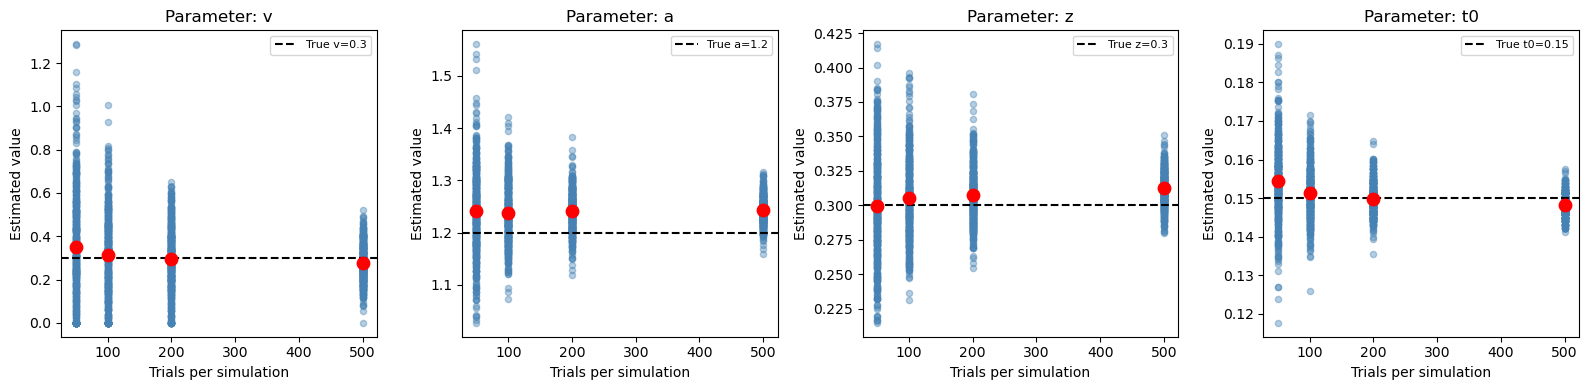

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = ['v', 'a', 'z', 't0']
true_vals = [0.3, 1.2, 0.3,0.15]

for i, (param, true_val) in enumerate(zip(params, true_vals)):
    ax = axes[i]
    for n in sample_sizes:
        subset = df[df['n_trials'] == n]
        estimates = subset[f'est_{param}']
        ax.scatter([n] * len(estimates), estimates, 
                  alpha=0.4, s=20, color='steelblue')
        ax.scatter(n, estimates.mean(), 
                  s=80, color='red', zorder=5)
    
    ax.axhline(true_val, color='black', linestyle='--', 
               linewidth=1.5, label=f'True {param}={true_val}')
    ax.set_xlabel('Trials per simulation')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'Parameter: {param}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('recovery_plot_500_03.png', dpi=150)
plt.show()

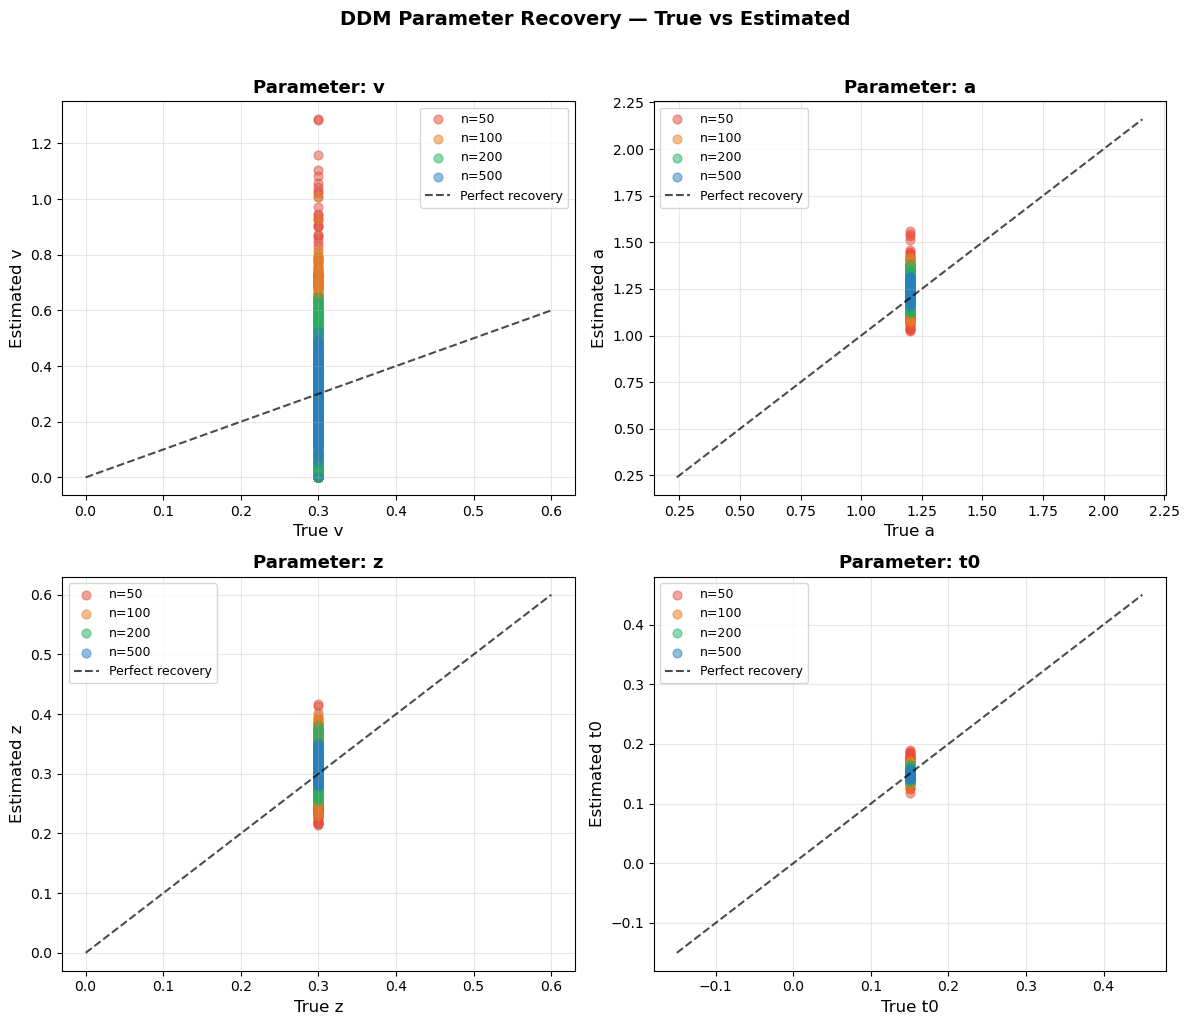

Figure saved as recovery_scatter_500_03.png


In [62]:
df = pd.read_csv('recovery_results_500_03.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
params = ['v', 'a', 'z', 't0']
true_vals = {'v': 0.3, 'a': 1.2, 'z': 0.3, 't0': 0.15}
colors = {50: '#e74c3c', 100: '#e67e22', 200: '#27ae60', 500: '#2980b9'}
labels = {50: 'n=50', 100: 'n=100', 200: 'n=200', 500: 'n=500'}

for idx, param in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    for n in [50, 100, 200, 500]:
        subset = df[df['n_trials'] == n]
        ax.scatter(
            subset[f'true_{param}'],
            subset[f'est_{param}'],
            alpha=0.5, s=40,
            color=colors[n],
            label=labels[n]
        )
    
    # Perfect recovery diagonal
    true_val = true_vals[param]
    spread = max(0.3, abs(true_val) * 0.8)
    lims = [true_val - spread, true_val + spread]
    ax.plot(lims, lims, 'k--', linewidth=1.5, 
            alpha=0.7, label='Perfect recovery')
    
    ax.set_xlabel(f'True {param}', fontsize=12)
    ax.set_ylabel(f'Estimated {param}', fontsize=12)
    ax.set_title(f'Parameter: {param}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DDM Parameter Recovery — True vs Estimated', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('recovery_scatter_500_03.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recovery_scatter_500_03.png")